### Notebook Overview - Feature Engineering

This notebook serves as the bridge between the initial Exploratory Data Analysis (EDA) and the Modeling phase. Following the findings in 01_eda.ipynb, we are now transforming the raw Spotify data into a format optimized for Machine Learning algorithms.

#### Objectives of this Phase:

Data Retrieval: Load the serialized data stored in Parquet format to ensure 100% data type integrity from the EDA stage.

Feature Construction: Create an ad_music_ratio to capture the relationship between weekly ad exposure and daily listening habits.

Categorical feature Encoding: Transform nominal variables (gender, country, subscription_type, device_type) into numerical format using One-Hot Encoding.

Feature Scaling: Standardize numerical features using StandardScaler to ensure that variables with larger ranges (like listening_time) do not disproportionately influence models like KNN or Logistic Regression.

Data Save: Save the final processed features (X) and target (y) for use in the Baseline Modeling notebook.

### Initial Setup & Data Loading

Load data from the paraquet file


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the cleaned data from the EDA stage
df = pd.read_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/spotify_eda_cleaned.parquet')

# Confirm data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


###  Create Visualization Folder

In [10]:
# Create Visualization Folder
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dedicated folder for Capstone visualizations
viz_folder = '/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures'
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)

### Correlation Heatmap For Features w.r.t churn

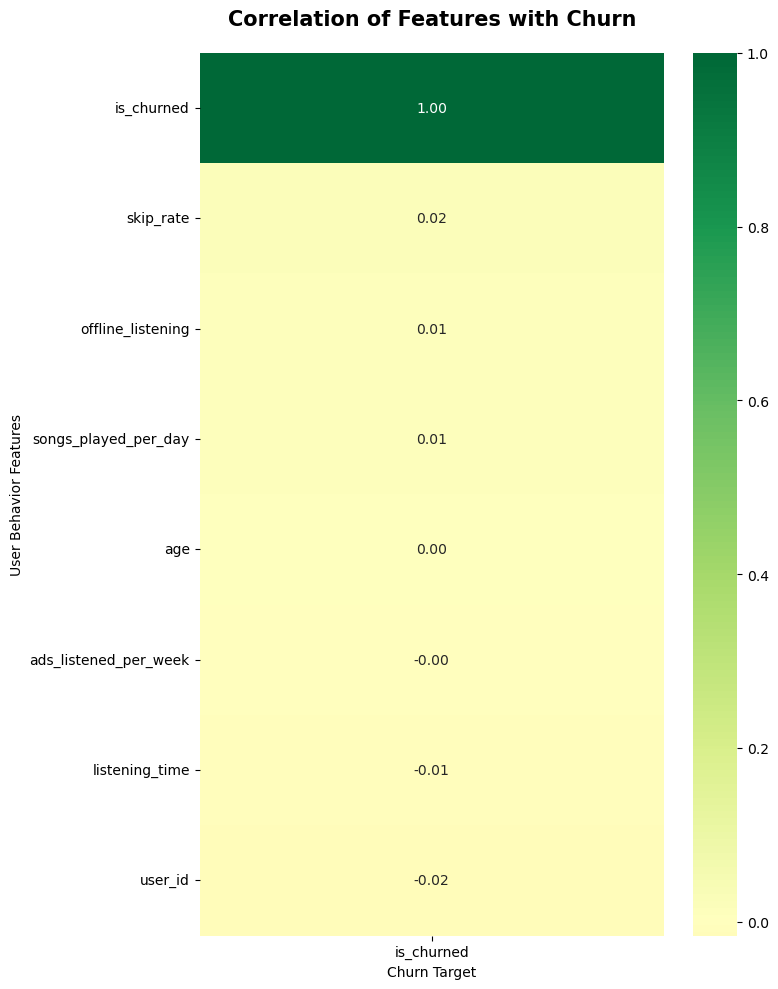

Correlation heatmap saved to: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/feature_churn_correlation.png


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
# We focus on the correlation with 'is_churned'
corr_matrix = df.select_dtypes(include=['number']).corr()
churn_corr = corr_matrix[['is_churned']].sort_values(by='is_churned', ascending=False)

# 2. Plot the Heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(churn_corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")

plt.title('Correlation of Features with Churn', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Churn Target')
plt.ylabel('User Behavior Features')

# 3. Save to your new visualizations folder
save_path = os.path.join(viz_folder, 'feature_churn_correlation.png')
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Correlation heatmap saved to: {save_path}")

### Correlation heatmap

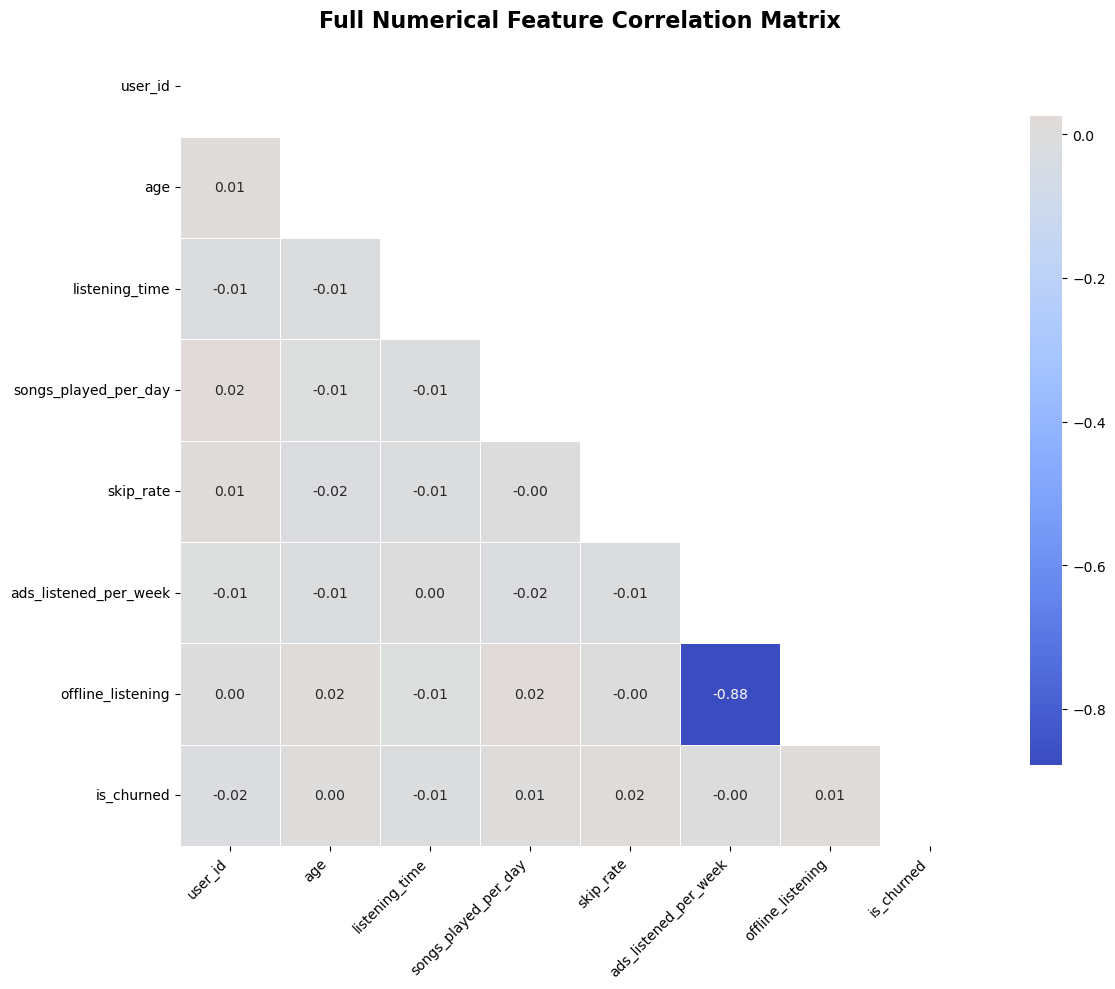

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select only numerical columns
# We use df_model (from cell 26) or df_encoded if you've already run dummies
numerical_df = df.select_dtypes(include=[np.number])

# 2. Calculate the full correlation matrix
full_corr = numerical_df.corr()

# 3. Generate a mask for the upper triangle 
# (This makes it easier to read by removing redundant mirrored values)
mask = np.triu(np.ones_like(full_corr, dtype=bool))

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(full_corr, mask=mask, annot=True, cmap='coolwarm', center=0, 
            fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Full Numerical Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# 5. Save to your dedicated visualizations folder
save_path = os.path.join(viz_folder, 'full_feature_heatmap.png')
plt.tight_layout()
plt.savefig(save_path, dpi=300)
plt.show()

### Feature Selection

Removing user_id from the modeling dataset. As a unique identifier, it contains no predictive power so we will remove the feature.

In [26]:
# 1. Drop the user_id column as we cannot use it for prediction
df_model = df.drop(columns=['user_id'])

# 2. Domain Feature Construction: Ad-to-Music Ratio
# We multiply daily listening_time by 7 to get a weekly estimate to match ads_listened_per_week
# Adding 1 to denominator to prevent division by zero
df_model['ad_music_ratio'] = df_model['ads_listened_per_week'] / ((df_model['listening_time'] * 7) + 1)

# 3. New Feature: Average Song Length
# We add 1 to the denominator to prevent division by zero for users with 0 songs played
df_model['avg_song_length'] = df_model['listening_time'] / (df_model['songs_played_per_day'] + 1)

# Display the first few rows to verify the new features
df_model[['listening_time', 'songs_played_per_day', 'avg_song_length', 'ad_music_ratio']].head()

,listening_time,songs_played_per_day,avg_song_length,ad_music_ratio
0,26,23,1.083333,0.169399
1,141,62,2.238095,0.000000
2,199,38,5.102564,0.000000
3,36,2,12.000000,0.000000
4,250,57,4.310345,0.000000


### Categorical Encoding

In [27]:
# 1. Categorical Encoding (One-Hot Encoding)
# This handles gender, country, subscription_type, and device_type
df_encoded = pd.get_dummies(
    df_model,
    columns=['gender', 'country', 'subscription_type', 'device_type'],
    drop_first=True,
    dtype=int)  # This forces 0/1 instead of True/False

# 2. Final Verification
print(f"Original feature count: {df.shape[1]}")
print(f"New feature count after encoding: {df_encoded.shape[1]}")
df_encoded.head()

Original feature count: 12
New feature count after encoding: 23


,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned,ad_music_ratio,avg_song_length,gender_Male,...,country_FR,country_IN,country_PK,country_UK,country_US,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Mobile,device_type_Web
0,54,26,23,0.20,31,0,1,0.169399,1.083333,0,...,0,0,0,0,0,1,0,0,0,0
1,33,141,62,0.34,0,1,0,0.000000,2.238095,0,...,0,0,0,0,0,0,0,0,0,1
2,38,199,38,0.04,0,1,1,0.000000,5.102564,1,...,0,0,0,0,0,0,1,0,1,0
3,22,36,2,0.31,0,1,0,0.000000,12.000000,0,...,0,0,0,0,0,0,0,1,1,0
4,29,250,57,0.36,0,1,1,0.000000,4.310345,0,...,0,0,0,0,1,0,0,0,1,0


### Scale the features

In [28]:
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (y)
# We drop 'is_churned' because we only want to transform the input features
X = df_encoded.drop(columns=['is_churned'])
y = df_encoded['is_churned']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original feature count: {X.shape[1]}")
print(f"Final feature count after expansion: {X_scaled.shape[1]}")

Original feature count: 22
Final feature count after expansion: 22


### Save the final features

In [29]:
# Create the DataFrame using the scaled data and the polynomial feature names
X_final_df = pd.DataFrame(X_scaled, columns=X.columns)

print(X_final_df.head())

# Save it as Parquet to preserve the names and data types
X_final_df.to_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/X_final_processed.parquet', index=False)

# Convert Series to DataFrame to make it Parquet-compatible
y.to_frame().to_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/y_final_target.parquet', index=False)

print("Target variable saved as Parquet.")

        age  listening_time  songs_played_per_day  skip_rate  \
0  1.282452       -1.524434             -0.953574  -0.576827   
1 -0.365956       -0.155555              0.417349   0.229702   
2  0.026522        0.534836             -0.426296  -1.498575   
3 -1.229408       -1.405401             -1.691763   0.056875   
4 -0.679939        1.141904              0.241590   0.344921   

   ads_listened_per_week  offline_listening  ad_music_ratio  avg_song_length  \
0               1.766611          -1.721720        4.044550        -0.450635   
1              -0.509938           0.580814       -0.305042        -0.351166   
2              -0.509938           0.580814       -0.305042        -0.104427   
3              -0.509938           0.580814       -0.305042         0.489702   
4              -0.509938           0.580814       -0.305042        -0.172667   

   gender_Male  gender_Other  ...  country_FR  country_IN  country_PK  \
0    -0.711952     -0.703795  ...   -0.375585   -0.380337   -